# Econ 521 — Lab 2
## Analyzing and Designing a Randomized Controlled Trial


Last week we established what randomization buys you. This week we do the work: take a real
experiment apart, get the standard errors right, test the null without assuming a distribution
at all, and then run the calculation you should have done *before* collecting any data.

**Running example.** Thornton, Rebecca L. (2008), "The Demand for, and Impact of, Learning HIV
Status," *American Economic Review* 98(5): 1829–1863. In rural Malawi, respondents were tested
for HIV and then randomly offered a cash incentive to collect their results at a nearby voluntary
counseling and testing (VCT) center. The incentive was randomized at the individual level;
distance to the center was randomized at the village level. Outcome: whether they came and got
their results.


In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
rng = np.random.default_rng(20260911)

from causaldata import thornton_hiv, ri

---
## §1 The data, attrition, and balance

**Variables.** `got` = collected HIV results (outcome); `any` = offered any cash incentive
(treatment); `tinc` = value of the incentive in dollars; `distvct` = distance to the VCT center
in km; `villnum` = village; `age`; `hiv2004` = HIV positive at the 2004 test.

First move on any dataset, always: look at what is missing and why.

In [2]:
thornton = thornton_hiv.load_pandas().data
print(thornton.shape)
print("\nmissing values by column:")
print(thornton.isna().sum().to_string())
thornton.describe().T

(4820, 7)

missing values by column:
villnum      27
got        1926
distvct       0
tinc       1919
any        1919
age         441
hiv2004    1926


,count,mean,std,min,25%,50%,75%,max
villnum,"4,793.0000",63.4776,48.3118,1.0000,14.0000,57.0000,111.0000,145.0000
got,"2,894.0000",0.6966,0.4598,0.0000,0.0000,1.0000,1.0000,1.0000
distvct,"4,820.0000",2.0026,1.2565,0.0000,1.0299,1.6748,2.7429,5.1916
tinc,"2,901.0000",0.9880,0.9014,0.0000,0.0946,0.9456,1.8912,2.8368
any,"2,901.0000",0.7659,0.4235,0.0000,1.0000,1.0000,1.0000,1.0000
age,"4,379.0000",33.6517,13.1629,11.0000,23.0000,32.0000,43.0000,84.0000
hiv2004,"2,894.0000",0.0591,0.2555,-1.0000,0.0000,0.0000,0.0000,1.0000


Two things should bother you.

**First, the missing-value pattern is not random across columns.** Roughly 1,900 rows are missing
`got`, `any`, `tinc`, and `hiv2004` simultaneously. Those are people who were surveyed but never
tested in 2004, so they were never eligible for the incentive experiment. They are not attrition
from the experiment; they were never in it. Dropping them is a decision about the *population*
your estimate describes, not a data-cleaning nicety, and you should say so in the paper.

**Second, look at the minimum of `hiv2004`.** It is $-1$. HIV status is supposed to be a 0/1
indicator. A value outside the logical range is almost always a missing-data sentinel that
somebody forgot to convert, and if you leave it in, it will silently enter every mean, every
regression, and every balance table you produce. Find these before they find you.

### Exercise 1 (6 min)

Build the analysis sample and a summary table.

1. Keep rows with non-missing `got`, `any`, `age`, `distvct`, and `hiv2004`.
2. Drop the $-1$ codes in `hiv2004`.
3. Produce a table with the **mean, standard deviation, min, and max** of `got`, `any`, `tinc`,
   `age`, `hiv2004`, `distvct`, and report $n$ and the number of villages underneath it.
4. Then produce a **balance table**: mean of `age`, `hiv2004`, `distvct` by treatment status,
   the difference, and a $p$-value for the difference.

Before you look at step 4: what do you *expect* the balance table to show, and what would you
conclude if `distvct` were imbalanced?

In [3]:
# ---- EXERCISE 1 -------------------------------------------------------------
d = thornton.dropna(subset=["got", "any", "age", "distvct", "hiv2004"]).copy()



In [4]:
# ---- EXERCISE 1, part 4: balance table --------------------------------------

# -----------------------------------------------------------------------------


**What you should find:** $n = 2{,}816$ in 119 villages. `hiv2004` and `distvct` are balanced.
`age` is **not** — the incentive group is about 1.6 years older, with $p \approx 0.007$.

Do not skip past that. It is the most useful thing in the table, and here is how to think about
it. The imbalance is 1.6 years on a mean of 33, roughly a tenth of a standard deviation. It is
detectable because $n$ is large, not because it is large. So the question is not "did we cross
0.05" but **"could a 1.6-year age gap plausibly generate a 45 percentage point difference in
collecting HIV results?"** Almost certainly not — and you can check by putting age in the
regression in §3 and watching the coefficient not move.

Two further caveats worth stating out loud. First, we are working with a *subsample*: we dropped
everyone missing any of five variables, and a subsample of a balanced sample need not be
balanced. If dropping observations creates imbalance, that is a differential attrition problem,
not a randomization problem, and it deserves its own paragraph in your paper. Second, recall from
last week that testing three covariates gives you about a 14% chance of one false rejection.
Report the balance table, discuss what is imbalanced, show it does not drive the result. Do not
either hide it or panic about it.

`distvct` is also worth flagging: it was randomized *at the village level*, which will matter
again in §5.

---
## §2 Difference in means = OLS, and the right standard error

Under randomization, $E[Y \mid D=1] - E[Y \mid D=0] = \text{ATE}$, so estimating the ATE is just
comparing two means. Three routes to the same number:

In [11]:
treated = d.loc[d["any"] == 1, "got"]
control = d.loc[d["any"] == 0, "got"]

print(f"1. Raw difference in means : {treated.mean() - control.mean():.4f}")

welch = stats.ttest_ind(treated, control, equal_var=False)
print(f"2. Welch t-test            : t = {welch.statistic:.3f}")

ols = smf.ols("got ~ any", data=d).fit(cov_type="HC1")
print(f"3. OLS with HC1 errors     : b = {ols.params['any']:.4f}, t = {ols.tvalues['any']:.3f}")
print(f"\ncontrol mean = {control.mean():.3f}")
ols.summary().tables[1]

1. Raw difference in means : 0.4479
2. Welch t-test            : t = 21.351
3. OLS with HC1 errors     : b = 0.4479, t = 21.359

control mean = 0.341


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,0.3414,0.019,17.893,0.000,0.304,0.379
any,0.4479,0.021,21.359,0.000,0.407,0.489


The Welch $t$ and the heteroskedasticity-robust OLS $t$ agree to three decimals. That is not a
coincidence: allowing unequal variances across arms *is* what HC1 does in this regression. If
someone asks you whether to use a $t$-test or a regression, the honest answer is that the choice
does not exist — but the regression generalizes, so use the regression.

**Substance:** offering any cash incentive raised the probability of collecting HIV results from
about **34%** to about **79%**, an effect of roughly **45 percentage points**. This is a very
large effect for a very small amount of money, and it is the paper's headline: demand for
information about your own HIV status is extremely sensitive to trivial transaction costs.

### Now the standard errors

The rule is: **cluster at the level at which treatment was assigned.** Incentives were randomized
to individuals, so individual-level robust errors are defensible. But outcomes within a village
are correlated — people share a VCT center, a road, a rainy season — so let us see what
clustering does anyway.

In [12]:
fits = {
    "Classical (iid)": smf.ols("got ~ any", data=d).fit(),
    "Robust (HC1)":    smf.ols("got ~ any", data=d).fit(cov_type="HC1"),
    "Clustered by village": smf.ols("got ~ any", data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d.villnum}),
}
pd.DataFrame({k: {"coef": f.params["any"], "std. error": f.bse["any"],
                  "t": f.tvalues["any"]} for k, f in fits.items()}).T

,coef,std. error,t
Classical (iid),0.4479,0.0193,23.2361
Robust (HC1),0.4479,0.0210,21.3591
Clustered by village,0.4479,0.0229,19.5385


Here the inflation is mild — the effect is enormous relative to any of these standard errors, so
nothing turns on the choice. **Do not generalize from that.** In §5 you will see a design where
clustering changes the effective sample size by a factor of fifty. The reason it is mild here is
that the treatment varies *within* village; when treatment is assigned *to* whole clusters, the
picture changes completely.

### Exercise 2 (5 min) — dose response

`any` throws away information: `tinc` records the actual incentive amount, and Thornton
randomized the amount too. Estimate the effect of the incentive *amount* on `got`, with village
clusters. Then add `any` and `tinc` to the same regression.

Interpret both coefficients in the second specification. What is the economic content of the
gap between the effect of "getting any money at all" and the effect of "getting one more dollar"?

In [13]:
# ---- EXERCISE 2 -------------------------------------------------------------
cl = {"groups": d.villnum}

dose  = smf.ols("got ~ tinc", data=d).fit(cov_type="cluster", cov_kwds=cl)        # got ~ tinc, clustered
both  = smf.ols("got ~ any + tinc", data=d).fit(cov_type="cluster", cov_kwds=cl)  # got ~ any + tinc, clustered

for name, m in [("got ~ tinc", dose), ("got ~ any + tinc", both)]:
    print(name)
    print(m.summary().tables[1])
    print()
# -----------------------------------------------------------------------------


got ~ tinc
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5129      0.021     24.882      0.000       0.472       0.553
tinc           0.1770      0.011     16.033      0.000       0.155       0.199

got ~ any + tinc
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3414      0.024     14.380      0.000       0.295       0.388
any            0.3394      0.027     12.741      0.000       0.287       0.392
tinc           0.0842      0.012      6.948      0.000       0.060       0.108



**What to notice:** almost all of the action is in `any`, not in `tinc`. Going from zero to *any*
money moves behavior enormously; going from a small amount to a larger amount moves it much less.
That pattern is hard to reconcile with a pure "cost of travel" story and much easier to reconcile
with something like a salience or reminder effect. Thornton discusses exactly this. It is also a
nice illustration of a point from Thursday: **treatment is a bundle**, and a single binary
indicator can hide the mechanism you actually care about.

---
## §3 Covariate adjustment and precision

Randomization means you do not *need* controls for identification. So why does every experimental
paper have them? For precision: covariates that predict the outcome soak up residual variance and
shrink the standard error on the treatment coefficient.

There is a catch, and it has a literature. Freedman (2008) showed that naively adding controls to
a randomized experiment can be *less* efficient than not adding them, and introduces small-sample
bias. Lin (2013) showed the fix: **center the covariates and interact them with treatment.** Three
specifications:

- **CL** — classical, no adjustment: $Y = \alpha + \tau D + \varepsilon$
- **CRA** — classical regression adjustment: $Y = \alpha + \tau D + X'\beta + \varepsilon$
- **IRA** — interacted (Lin) adjustment: $Y = \alpha + \tau D + \tilde X'\beta + (D \cdot \tilde X)'\gamma + \varepsilon$, with $\tilde X = X - \bar X$

Centering matters. Without it, $\tau$ is the effect at $X = 0$ — a 0-year-old living 0 km from the
clinic — rather than the average effect.

In [14]:
for v in ["age", "distvct", "hiv2004"]:
    d[f"{v}_c"] = d[v] - d[v].mean()          # centered covariates

cl = {"groups": d.villnum}
CL  = smf.ols("got ~ any", data=d).fit(cov_type="cluster", cov_kwds=cl)
CRA = smf.ols("got ~ any + age_c + distvct_c + hiv2004_c",
              data=d).fit(cov_type="cluster", cov_kwds=cl)
IRA = smf.ols("got ~ any*age_c + any*distvct_c + any*hiv2004_c",
              data=d).fit(cov_type="cluster", cov_kwds=cl)

pd.DataFrame({k: {"coef on 'any'": m.params["any"], "std. error": m.bse["any"], "R-squared": m.rsquared}
              for k, m in [("CL", CL), ("CRA", CRA), ("IRA", IRA)]}).T

,coef on 'any',std. error,R-squared
CL,0.4479,0.0229,0.1610
CRA,0.4473,0.0221,0.1705
IRA,0.4459,0.0217,0.1716


Two lessons.

**The point estimate barely moves.** That is the signature of a successful randomization. If
adding controls to an experiment shifts your coefficient substantially, something is wrong —
either the randomization failed, or you have conditioned on a post-treatment variable, or there
is differential attrition.

**The standard error falls a little.** Not much here, because `age`, `distvct`, and `hiv2004` are
weak predictors of `got`. The single best precision-buying covariate is almost always a
**baseline measure of the outcome itself**, which Thornton does not have for this outcome. In
industry this idea is repackaged as CUPED (residualize the outcome on pre-period data, then
compare arms); it is the same variance reduction, and you get it for free at design time by
collecting a baseline survey. Budget for one.

**A warning you will need for referee reports:** never control for anything measured *after*
randomization. A post-treatment control can be affected by treatment, and conditioning on it
reintroduces exactly the selection problem randomization was supposed to solve.

---
## §4 Randomization inference

Everything so far leaned on asymptotic normality. Fisher's alternative asks a sharper, more
finite-sample question. Under the **sharp null**

$$H_0: \delta_i = 0 \quad \text{for every } i,$$

every unit's outcome would be identical under any other assignment. So we can compute the test
statistic under *every* assignment the experiment could have produced and see where the realized
one sits in that distribution. No distributional assumption anywhere.

Note the difference from what you usually test. The usual null is $H_0: E[\delta_i] = 0$ — the
*average* effect is zero, which is compatible with large effects that cancel out. Fisher's null
says nobody was affected at all. Stronger claim, exact test.

Start with eight people, four treated. There are $\binom{8}{4} = 70$ possible assignments.

In [15]:
small = ri.load_pandas().data
print(small.to_string(index=False))

y   = small.y.astype(float).values
n, k = len(y), int(small.d.sum())
observed = y[small.d == 1].mean() - y[small.d == 0].mean()
print(f"\nobserved difference in means: {observed:.3f}")

  name  d  y y0 y1
  Andy  1 10  . 10
   Ben  1  5  .  5
  Chad  1 16  . 16
Daniel  1  3  .  3
 Edith  0  5  5  .
 Frank  0  7  7  .
George  0  8  8  .
  Hank  0 10 10  .

observed difference in means: 1.000


70 possible assignments
exact one-sided p = 0.4286
exact two-sided p = 0.8571


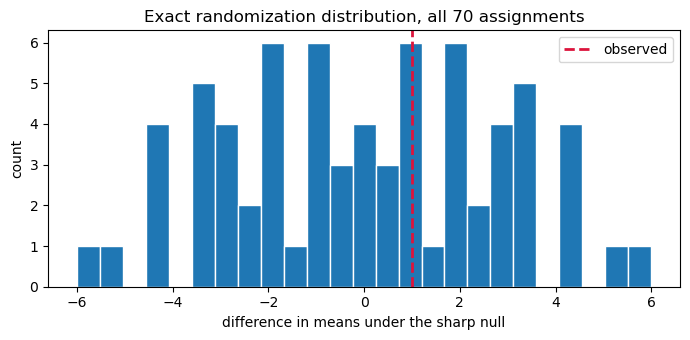

In [16]:
# enumerate every possible treatment assignment
null_dist = []
for idx in combinations(range(n), k):
    treat = np.zeros(n, dtype=bool)
    treat[list(idx)] = True
    null_dist.append(y[treat].mean() - y[~treat].mean())
null_dist = np.array(null_dist)

p_two = np.mean(np.abs(null_dist) >= abs(observed))
p_one = np.mean(null_dist >= observed)
print(f"{len(null_dist)} possible assignments")
print(f"exact one-sided p = {p_one:.4f}")
print(f"exact two-sided p = {p_two:.4f}")

plt.figure(figsize=(7, 3.5))
plt.hist(null_dist, bins=25, edgecolor="white")
plt.axvline(observed, color="crimson", linestyle="--", linewidth=2, label="observed")
plt.xlabel("difference in means under the sharp null")
plt.ylabel("count")
plt.title("Exact randomization distribution, all 70 assignments")
plt.legend()
plt.tight_layout()
plt.show()

The observed difference of $+1.0$ sits comfortably inside the distribution: about 43% of the
possible assignments would have produced something at least this large. We cannot reject the
sharp null. With eight observations, we were never going to.

### Exercise 3 (5 min)

Thornton's sample is far too large to enumerate — $\binom{2816}{2211}$ is a number with hundreds
of digits — so we **approximate** the randomization distribution by drawing many permutations at
random.

Fill in the loop below: on each iteration, shuffle the treatment vector, recompute the difference
in means, and store it. Then compute the share of permutations at least as extreme as the truth.

Because incentives were randomized at the individual level, a plain shuffle is the right
permutation here. *If* treatment had been assigned to whole villages, what would you have to
change?

In [17]:
# ---- EXERCISE 3 -------------------------------------------------------------
y_t   = d["got"].values
treat = d["any"].values.astype(bool)
observed_t = y_t[treat].mean() - y_t[~treat].mean()

n_perm = 2_000
perm_stats = np.empty(n_perm)

for b in range(n_perm):
    shuffled = rng.permutation(treat)              # a random permutation of `treat`
    perm_stats[b] = y_t[shuffled].mean() - y_t[~shuffled].mean()  # difference in means under `shuffled`

p_ri = np.mean(np.abs(perm_stats) >= abs(observed_t))  # share of |perm_stats| >= |observed_t|
print(f"observed: {observed_t:.4f}    RI p-value: {p_ri:.4f}")
print(f"OLS/HC1 p-value for comparison: {ols.pvalues['any']:.2e}")
# -----------------------------------------------------------------------------


observed: 0.4479    RI p-value: 0.0000
OLS/HC1 p-value for comparison: 3.21e-101


You will get an RI $p$-value of 0 — in 2,000 permutations, not one produces anything near 45
percentage points. Correct reporting is $p < 1/2000$, not $p = 0$: randomization inference gives
you a resolution limit set by the number of draws.

Randomization inference is worth having in your toolkit for three situations that come up
constantly: **few treated clusters** (where cluster-robust errors are badly undersized), **skewed
or bounded outcomes**, and **any design too complicated for a standard formula** — stratified,
matched-pair, or staggered adoption. In every one of these, you can permute according to the
actual assignment mechanism and get an exact test.

---
## §5 Power, MDE, and the design effect

Everything above is *ex post*. Power analysis is *ex ante*, and it is the single highest-return
hour of work in an experimental project, because it is the only point at which you can still fix
the problem. Power is

$$\text{power} = \Pr(\text{reject } H_0 \mid H_1 \text{ true}).$$

Convention is 0.80: if there really is an effect of the size you specified, you find it 80% of
the time. Read that again — the *convention* accepts a 20% chance of missing a real effect.

Three quantities, and fixing any two pins down the third: **sample size**, **minimum detectable
effect (MDE)**, and **power**. In practice a budget fixes $n$, so you solve for the MDE and ask
whether it is smaller than any effect you would find interesting. If it is not, do not run the
experiment.

In [ ]:
power_analysis = smp.TTestIndPower()

# Standardized effect size (Cohen's d) = effect / sd of outcome
n_needed = power_analysis.solve_power(effect_size=0.20, power=0.80, alpha=0.05)
print(f"n per arm to detect d = 0.20 with 80% power: {np.ceil(n_needed):.0f}")

mde_d = power_analysis.solve_power(nobs1=500, power=0.80, alpha=0.05)
print(f"MDE (in sd units) with 500 per arm:          {mde_d:.3f}")

In [ ]:
sample_sizes  = np.arange(20, 3000, 20)
effect_sizes  = np.array([0.05, 0.10, 0.20, 0.50])

fig, ax = plt.subplots(figsize=(9, 4.5))
power_analysis.plot_power(dep_var="nobs", nobs=sample_sizes, effect_size=effect_sizes,
                          alpha=0.05, ax=ax, title=r"Power curves, $\alpha = 0.05$")
ax.axhline(0.80, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("n per arm")
plt.tight_layout()
plt.show()

Look at the shape, not the numbers. The curves are steep at small $n$ and flat at large $n$: going
from 100 to 300 per arm buys you a great deal, going from 2,000 to 2,200 buys almost nothing. And
the spacing between the curves is the expensive fact — **halving the effect you want to detect
roughly quadruples the sample you need**, because the MDE scales with $1/\sqrt{n}$.

This is why "we'll just add a few more observations" almost never rescues an underpowered design.

### Trust but verify

`solve_power` inverts a formula. Simulate the experiment and check that the formula tells the
truth.

In [ ]:
effect = 0.30                                       # in sd units
n_arm  = int(np.ceil(power_analysis.solve_power(effect_size=effect, power=0.80, alpha=0.05)))

rejections = 0
n_sims = 2_000
for _ in range(n_sims):
    ctrl = rng.normal(0.0,    1.0, n_arm)
    trt  = rng.normal(effect, 1.0, n_arm)
    rejections += stats.ttest_ind(trt, ctrl).pvalue < 0.05

print(f"formula says n = {n_arm} per arm for 80% power")
print(f"simulated power at that n: {rejections / n_sims:.3f}")

### Clustered assignment and the design effect

Here is the mistake that ruins more experiments than any other. Recall the example from
Thursday's notes: 30 hospitals, 15 treated and 15 control, 1,000 patients each. You have 30,000
observations. You do **not** have 30,000 independent observations. Treatment was assigned to
*hospitals*, so you have 30 independent units, and patients within a hospital are correlated.

The correction is the **design effect**:

$$\text{DEFF} = 1 + (m - 1)\rho,$$

where $m$ is the cluster size and $\rho$ is the intra-cluster correlation. Your effective sample
size is $n_{\text{eff}} = n / \text{DEFF}$, and the required $n$ scales up by DEFF.

In [ ]:
def design_effect(m, rho):
    return 1 + (m - 1) * rho

rows = []
for rho in [0.0, 0.01, 0.05, 0.10, 0.20]:
    deff = design_effect(m=1000, rho=rho)
    rows.append({"ICC (rho)": rho, "cluster size m": 1000, "DEFF": deff,
                 "effective n (of 30,000)": 30_000 / deff})
pd.DataFrame(rows)

Read the row for $\rho = 0.05$ — a completely unremarkable ICC for patients within a hospital.
DEFF is about **51**, so your 30,000 patients are worth roughly **590** independent observations.
Ignoring this does not make your study underpowered; it makes your standard errors about **seven
times too small**, which means your $t$-statistics are seven times too large and your "highly
significant" result is noise.

Notice also what the formula implies about design: because $m$ enters multiplied by $\rho$, adding
more patients *within* existing hospitals has sharply diminishing returns, while adding more
*hospitals* does not. When treatment is clustered, **the number of clusters is what buys power.**

### Where does the ICC come from?

You do not guess it. You estimate it from pilot data or from a comparable published study. The
ANOVA estimator compares between-cluster to within-cluster variance in the outcome.

In [ ]:
def icc_anova(data, outcome, cluster):
    '''ANOVA estimator of the intra-cluster correlation.'''
    g = data.groupby(cluster)[outcome]
    k, N = data[cluster].nunique(), len(data)
    msb = (g.count() * (g.mean() - data[outcome].mean())**2).sum() / (k - 1)
    msw = ((data[outcome] - g.transform("mean"))**2).sum() / (N - k)
    m0  = (N - (g.count()**2).sum() / N) / (k - 1)
    return (msb - msw) / (msb + (m0 - 1) * msw)

rho_hat = icc_anova(d, "got", "villnum")
print(f"average village size: {len(d) / d.villnum.nunique():.1f}")
print(f"estimated ICC of `got` across villages: {rho_hat:.3f}")

### Exercise 4 (6 min)

Suppose you are designing a follow-up to Thornton with a new, cheaper intervention — a text
message reminder instead of cash — and you must assign it **at the village level**, because you
cannot text some people in a village and not others without them talking to each other. (That is
a SUTVA argument, not a logistical one.)

1. Take the control-group mean and standard deviation of `got` from the data as your benchmark.
2. Compute the number of respondents per arm needed to detect a **5 percentage point** increase
   with 80% power, ignoring clustering.
3. Now account for clustering: village size $m = 24$ (the average in Thornton) and the ICC
   `rho_hat` you just estimated. Apply the design effect.
4. Convert to a number of **villages** per arm. Is this study feasible?

In [ ]:
# ---- EXERCISE 4 -------------------------------------------------------------
p0 = d.loc[d["any"] == 0, "got"].mean()
sd = d["got"].std()
print(f"control mean = {p0:.3f}, sd of outcome = {sd:.3f}")

mde_abs   = 0.05
effect_d  = mde_abs / sd      # standardize: absolute effect divided by sd

n_naive   = power_analysis.solve_power(effect_size=effect_d, power=0.80, alpha=0.05)  # respondents per arm ignoring clustering
deff      = design_effect(m=24, rho=rho_hat)     # design effect with m = 24 and rho_hat
n_cluster = n_naive * deff                        # respondents per arm accounting for clustering
villages  = n_cluster / 24                        # villages per arm

print(f"\nnaive n per arm      : {np.ceil(n_naive):.0f}")
print(f"design effect        : {deff:.2f}")
print(f"clustered n per arm  : {np.ceil(n_cluster):.0f}")
print(f"villages per arm     : {np.ceil(villages):.0f}")
# -----------------------------------------------------------------------------


**What you should find:** about **1,343** respondents per arm ignoring clustering. The ICC of
`got` across villages is about **0.065**, which with $m = 24$ gives a design effect of roughly
**2.5** — so you actually need about **3,350** respondents per arm, or **140 villages per arm**,
280 in total. Thornton worked with 119 villages. A 5 percentage point effect on this outcome is
not detectable at that scale, and the honest response is to redesign: target a larger effect,
find a covariate that cuts residual variance, stratify on the baseline take-up rate, or accept
that you are running a pilot rather than a test.

Note how modest that ICC is and how much damage it still does. An ICC of 0.065 sounds like
nothing. It more than doubles the sample you need.

That conversation is much cheaper to have now than after two years of fieldwork.

---

## Takeaways

1. Clean before you estimate. Out-of-range codes and non-random missingness change your estimand
   before they change your standard errors.
2. Difference in means, Welch $t$-test, and robust OLS are the same estimate. Use the regression,
   because it extends.
3. Cluster at the level of assignment. When treatment is assigned to clusters, the number of
   clusters is your real sample size.
4. Covariates buy precision, not identification — center and interact them (Lin), and never
   control for anything measured after randomization.
5. Randomization inference tests a sharp null exactly, and rescues you when asymptotics are
   unreliable: few clusters, skewed outcomes, exotic designs.
6. Do the power calculation before the experiment. The MDE scales with $1/\sqrt{n}$ and gets
   multiplied by the design effect, and no amount of clever estimation fixes an underpowered
   design after the fact.
